In [47]:
import numpy as np
import pandas as pd

import scipy.stats as sts

import matplotlib.pyplot as plt

%matplotlib inline

# 10.1i

In [36]:
# Reference from p.13, presentation session 11
alpha = np.array([0, np.pi/2, np.pi])

p = np.array([1/3, 1/3, 1/3])

x = np.sin(alpha)
y = np.cos(alpha)

print(x)
print(y)

[0.0000000e+00 1.0000000e+00 1.2246468e-16]
[ 1.000000e+00  6.123234e-17 -1.000000e+00]


In [37]:
Exy = np.sum(x * y * p)

In [39]:
Ex = np.sum(x * p)
Ey = np.sum(y * p)

covxy = Exy - Ex * Ey

print(Ex)
print(Ey)

0.33333333333333337
0.0


In [40]:
varx = np.sum((x**2) * p) - Ex**2
vary = np.sum((y**2) * p) - Ey**2

rho = covxy / np.sqrt(varx * vary)

print(varx)
print(vary)

0.22222222222222218
0.6666666666666666


In [41]:
print("\nE(XY) =", Exy)

print("\nCov(X,Y) =", covxy)

print("\nCorrelation coefficient =", rho)


E(XY) = -2.041077998578922e-17

Cov(X,Y) = -2.041077998578922e-17

Correlation coefficient = -5.3028761936245346e-17


# 10.2i

In [42]:
data = pd.DataFrame({
    "JanTemp": [
        44,38,35,31,47,42,15,22,26,30,45,65,58,37,22,19,21,11,22,27,
        45,12,25,23,21,2,24,8,13,11,27,24,14,27,34,31,0,26,21,28,
        33,24,24,38,31,24,49,44,18,7,32,33,19,9,13,14
    ],

    "Lat": [
        31.2,32.9,33.6,35.4,34.3,38.4,40.7,41.7,40.5,39.7,31.0,25.0,
        26.3,33.9,43.7,42.3,39.8,41.8,38.1,39.0,30.8,44.2,39.7,42.7,
        43.1,45.9,39.3,47.1,41.9,43.5,39.8,35.1,42.6,40.8,35.9,36.4,
        47.1,39.2,42.3,35.9,45.6,40.9,40.9,33.3,36.7,35.6,29.4,30.1,
        41.1,45.0,37.0,48.1,48.1,43.4,43.3,41.2
    ]
})

data.head()

,JanTemp,Lat
0,44,31.2
1,38,32.9
2,35,33.6
3,31,35.4
4,47,34.3


In [43]:
x = data["Lat"]
y = data["JanTemp"]

r, _ = sts.pearsonr(x, y)

r

np.float64(-0.8480352058672054)

In [44]:
B = 10000
boot_r = np.zeros(B)

for i in range(B):
    shuffled_y = np.random.permutation(y)
    boot_r[i] = np.corrcoef(x, shuffled_y)[0,1]

p_value = np.mean(np.abs(boot_r) >= abs(r))

print("\nBootstrap p-value =", p_value)


Bootstrap p-value = 0.0


In [45]:
alpha = 0.05

if p_value < alpha:
    print("\nReject H0")
    print("Conclusion: JanTemp and Lat are dependent.")
else:
    print("\nFail to reject H0")
    print("Conclusion: No evidence of dependence.")


Reject H0
Conclusion: JanTemp and Lat are dependent.


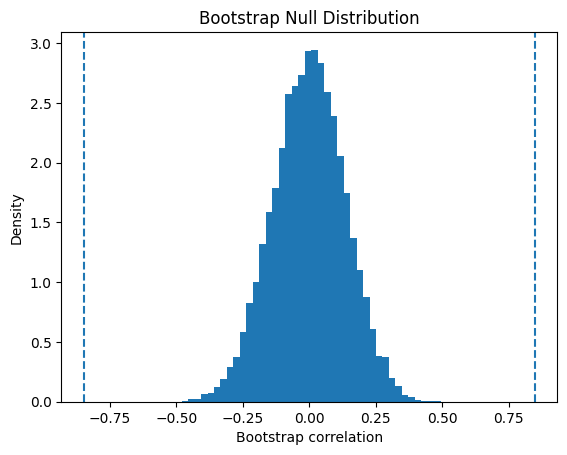

In [48]:
plt.hist(boot_r, bins=40, density=True)

plt.axvline(r, linestyle='dashed')
plt.axvline(-r, linestyle='dashed')

plt.xlabel("Bootstrap correlation")
plt.ylabel("Density")
plt.title("Bootstrap Null Distribution")

plt.show()